# 1.4.4 Smoothing Images

## Kernel Convolution

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [3]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [4]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [5]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [6]:
img

array([[2, 6, 1, 6, 3, 1, 2, 8, 3, 3, 6, 6],
       [4, 0, 7, 6, 6, 0, 7, 6, 7, 3, 5, 5],
       [2, 1, 0, 3, 2, 9, 9, 1, 3, 9, 3, 2],
       [7, 8, 3, 1, 5, 2, 3, 4, 2, 1, 5, 3],
       [6, 9, 0, 8, 2, 5, 2, 1, 7, 2, 2, 0],
       [2, 1, 6, 6, 6, 0, 8, 4, 3, 9, 0, 3],
       [0, 5, 6, 1, 4, 8, 5, 3, 8, 1, 7, 0],
       [1, 0, 2, 6, 0, 6, 1, 1, 0, 9, 9, 5],
       [8, 2, 6, 2, 9, 2, 9, 1, 0, 6, 1, 3],
       [1, 7, 2, 4, 3, 4, 0, 3, 1, 7, 0, 9],
       [1, 0, 9, 3, 4, 9, 1, 5, 0, 1, 2, 4],
       [9, 1, 2, 1, 8, 8, 3, 7, 9, 7, 4, 7]])

In [7]:
h,w=img.shape

In [8]:
print(h,w)

12 12


In [9]:
#[*range(-2,3)]

In [11]:
dst = np.zeros((h,w),dtype=int)

In [12]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [13]:
img

array([[2, 6, 1, 6, 3, 1, 2, 8, 3, 3, 6, 6],
       [4, 0, 7, 6, 6, 0, 7, 6, 7, 3, 5, 5],
       [2, 1, 0, 3, 2, 9, 9, 1, 3, 9, 3, 2],
       [7, 8, 3, 1, 5, 2, 3, 4, 2, 1, 5, 3],
       [6, 9, 0, 8, 2, 5, 2, 1, 7, 2, 2, 0],
       [2, 1, 6, 6, 6, 0, 8, 4, 3, 9, 0, 3],
       [0, 5, 6, 1, 4, 8, 5, 3, 8, 1, 7, 0],
       [1, 0, 2, 6, 0, 6, 1, 1, 0, 9, 9, 5],
       [8, 2, 6, 2, 9, 2, 9, 1, 0, 6, 1, 3],
       [1, 7, 2, 4, 3, 4, 0, 3, 1, 7, 0, 9],
       [1, 0, 9, 3, 4, 9, 1, 5, 0, 1, 2, 4],
       [9, 1, 2, 1, 8, 8, 3, 7, 9, 7, 4, 7]])

In [14]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, -18,  21,   2,  13, -23,  11,   1,  13, -12,   3,   0],
       [  0,  -6, -14,   3, -15,  23,  16, -18,  -7,  26,  -9,   0],
       [  0,  12,   3, -15,  13, -14,  -5,   9,  -7, -14,  11,   0],
       [  0,  21, -26,  23, -16,  14,  -9, -13,  20, -11,   1,   0],
       [  0, -18,  11,   3,  12, -27,  21,   1, -16,  30, -21,   0],
       [  0,  13,  10, -18,   1,  17,   0,  -6,  25, -29,  18,   0],
       [  0, -10, -10,  19, -25,  13, -17,  -1, -18,  20,  14,   0],
       [  0, -13,  16, -17,  29, -20,  32,  -9,  -8,   7, -14,   0],
       [  0,  23, -18,   6,  -9,   2, -17,   5,  -6,  20, -19,   0],
       [  0, -18,  29,  -6,  -7,  19, -13,   9, -16, -12,  -1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [15]:
img = cv2.imread('lena.png', 0)

In [16]:
h,w=img.shape

In [17]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [18]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [19]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [21]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

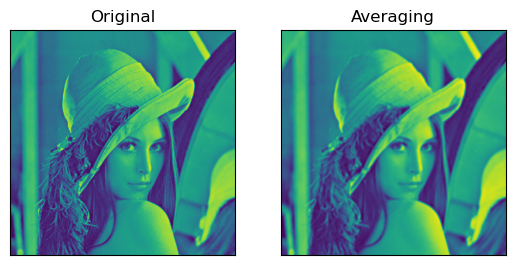

In [24]:
kernel = np.ones((5,5),np.float32)/25
blur = cv2.GaussianBlur
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()
